Machine Sensor Anomaly Detection using Isolation Forest


First 5 Rows:
     MachineID  Vibration_Hz  Temperature_C  Pressure_PSI  Acoustic_Noise_dB  \
0  M-SENS-4000         46.14           61.8         101.5               51.9   
1  M-SENS-4001        107.65           27.2         148.7               96.3   
2  M-SENS-4002         50.80           65.3         105.8               52.7   
3  M-SENS-4003         49.40           61.9         104.4               57.0   
4  M-SENS-4004         49.03           63.0         103.3               51.1   

   Rotation_RPM  Power_Consumption_kW  
0          1725                 13.24  
1          1020                 31.73  
2          1830                 14.40  
3          1697                 12.87  
4          1679                 14.37  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MachineID             600 non-n

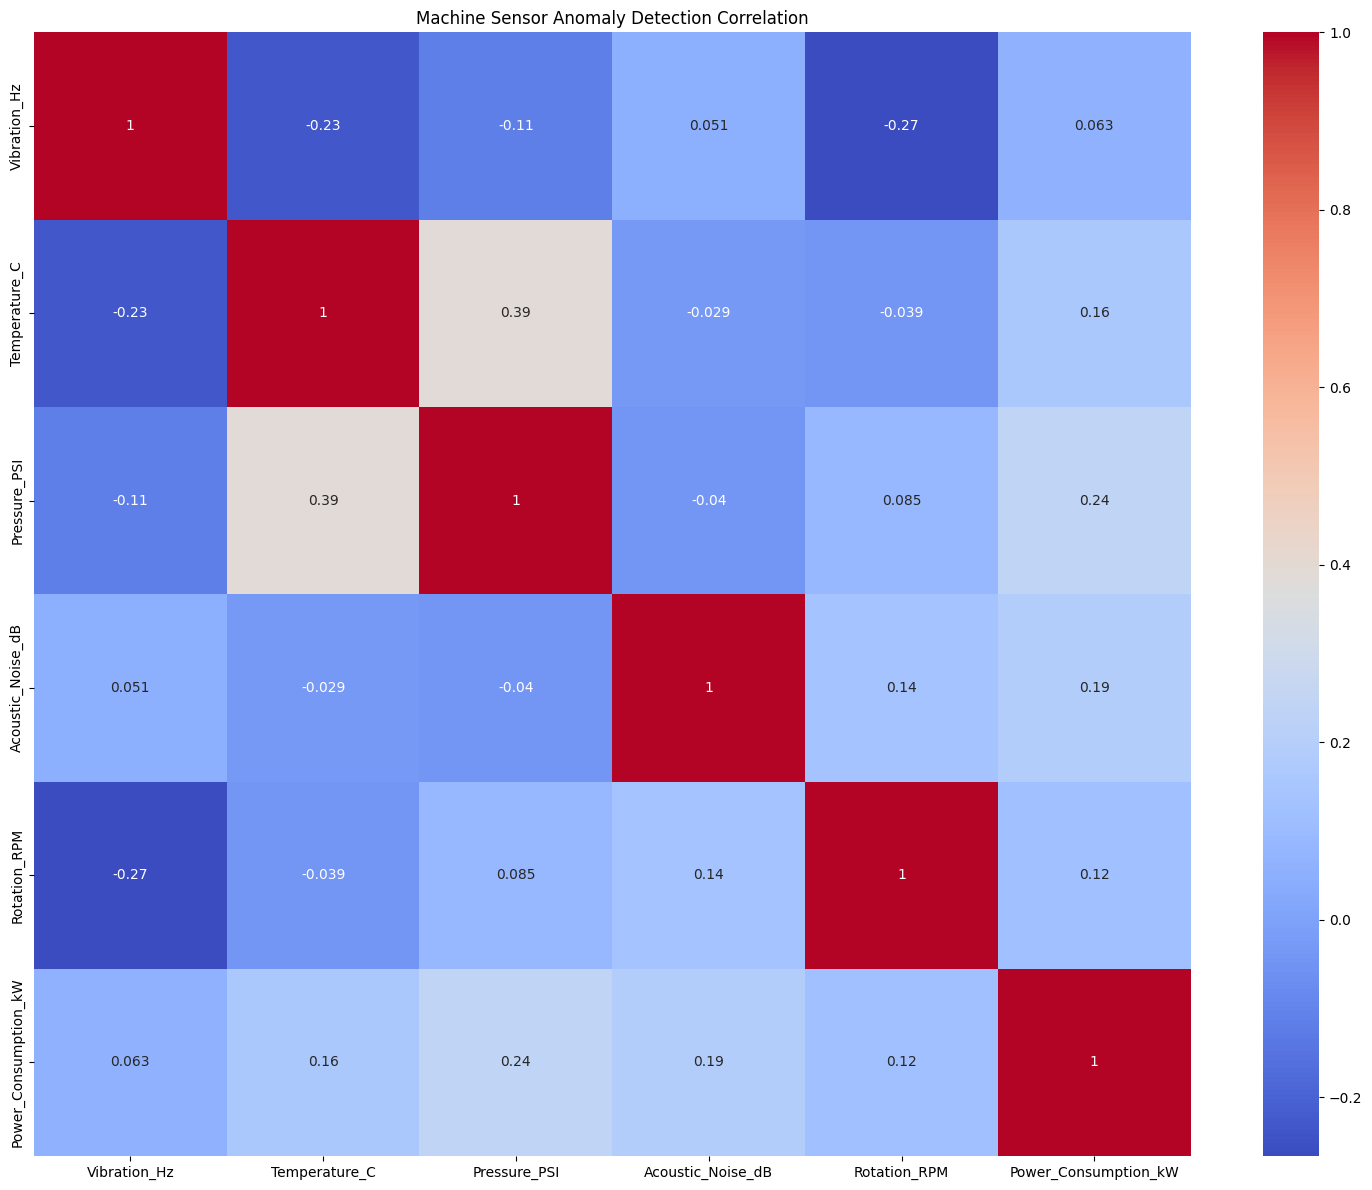

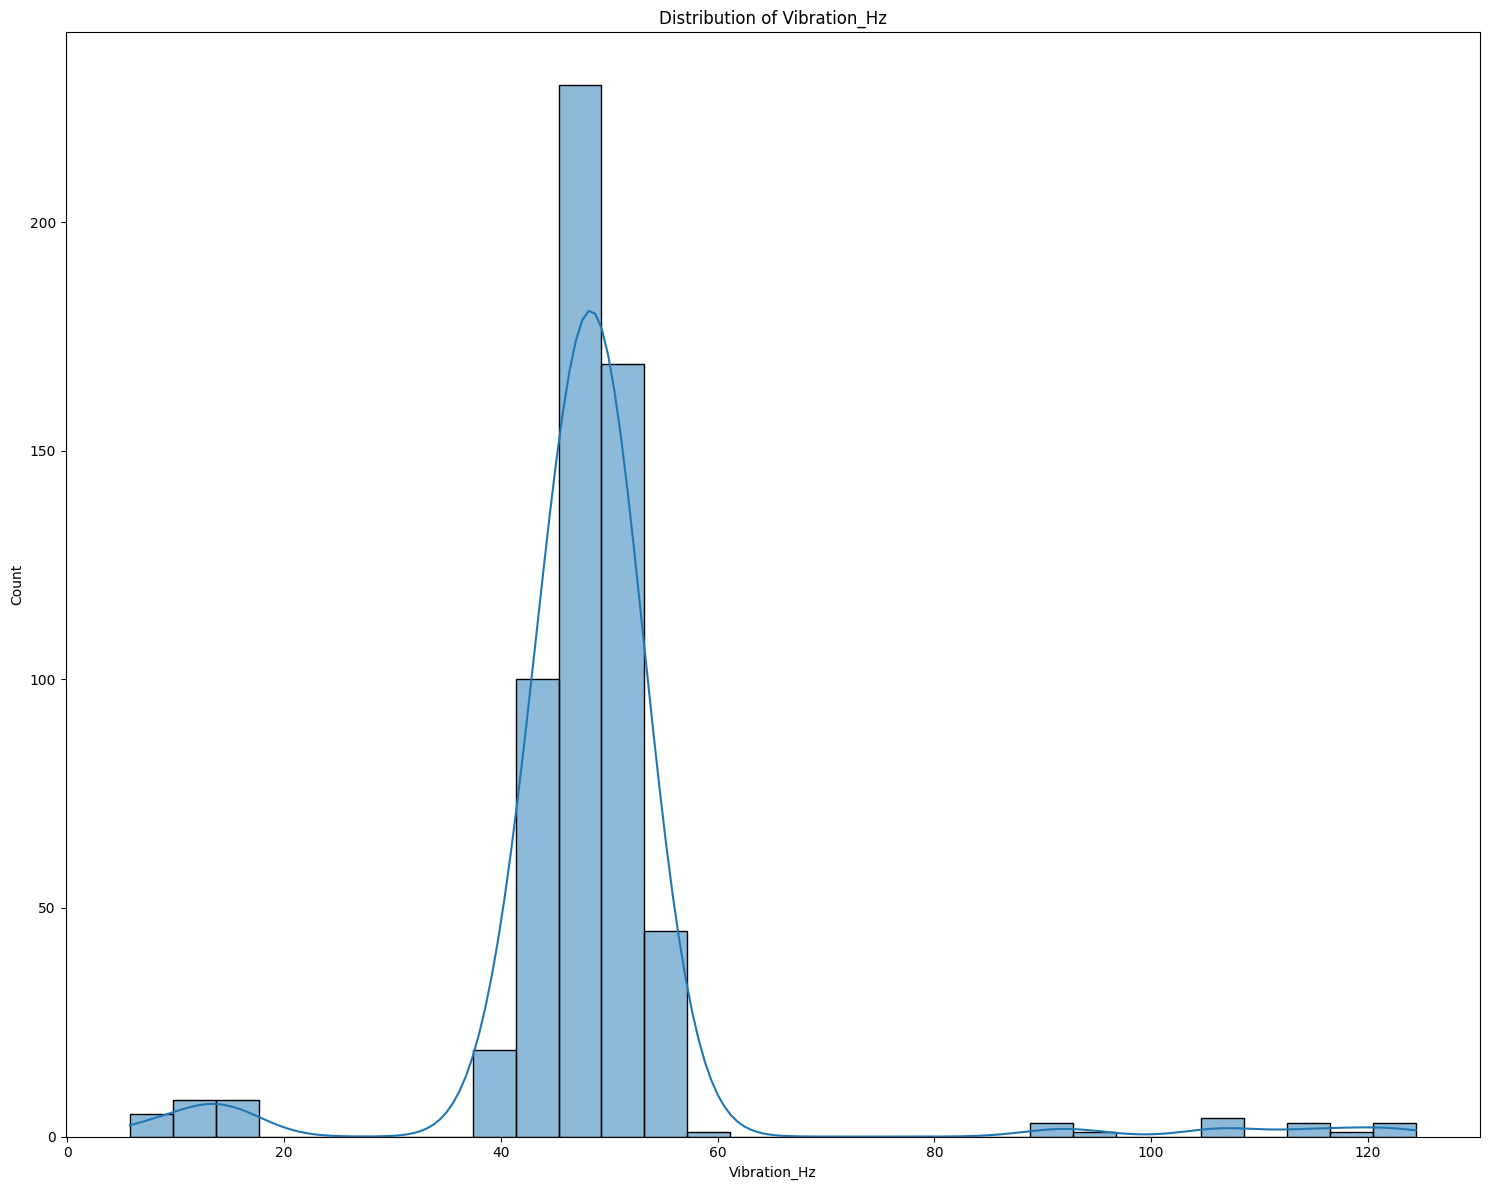

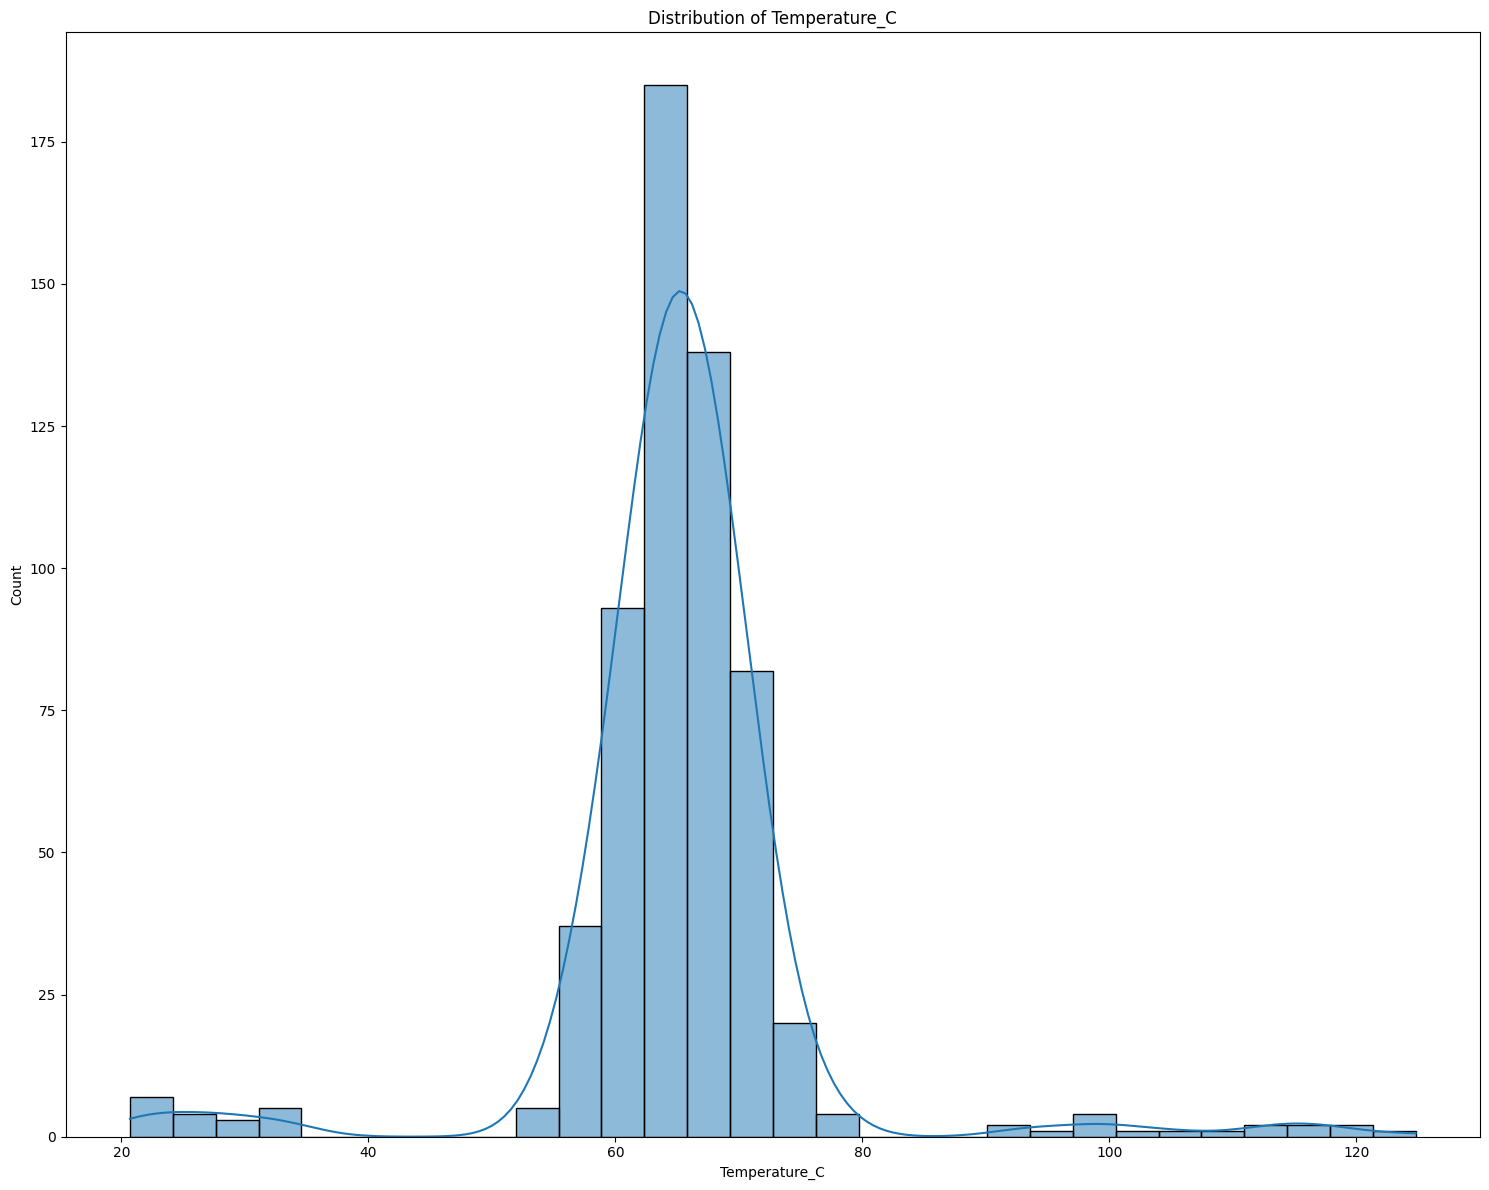

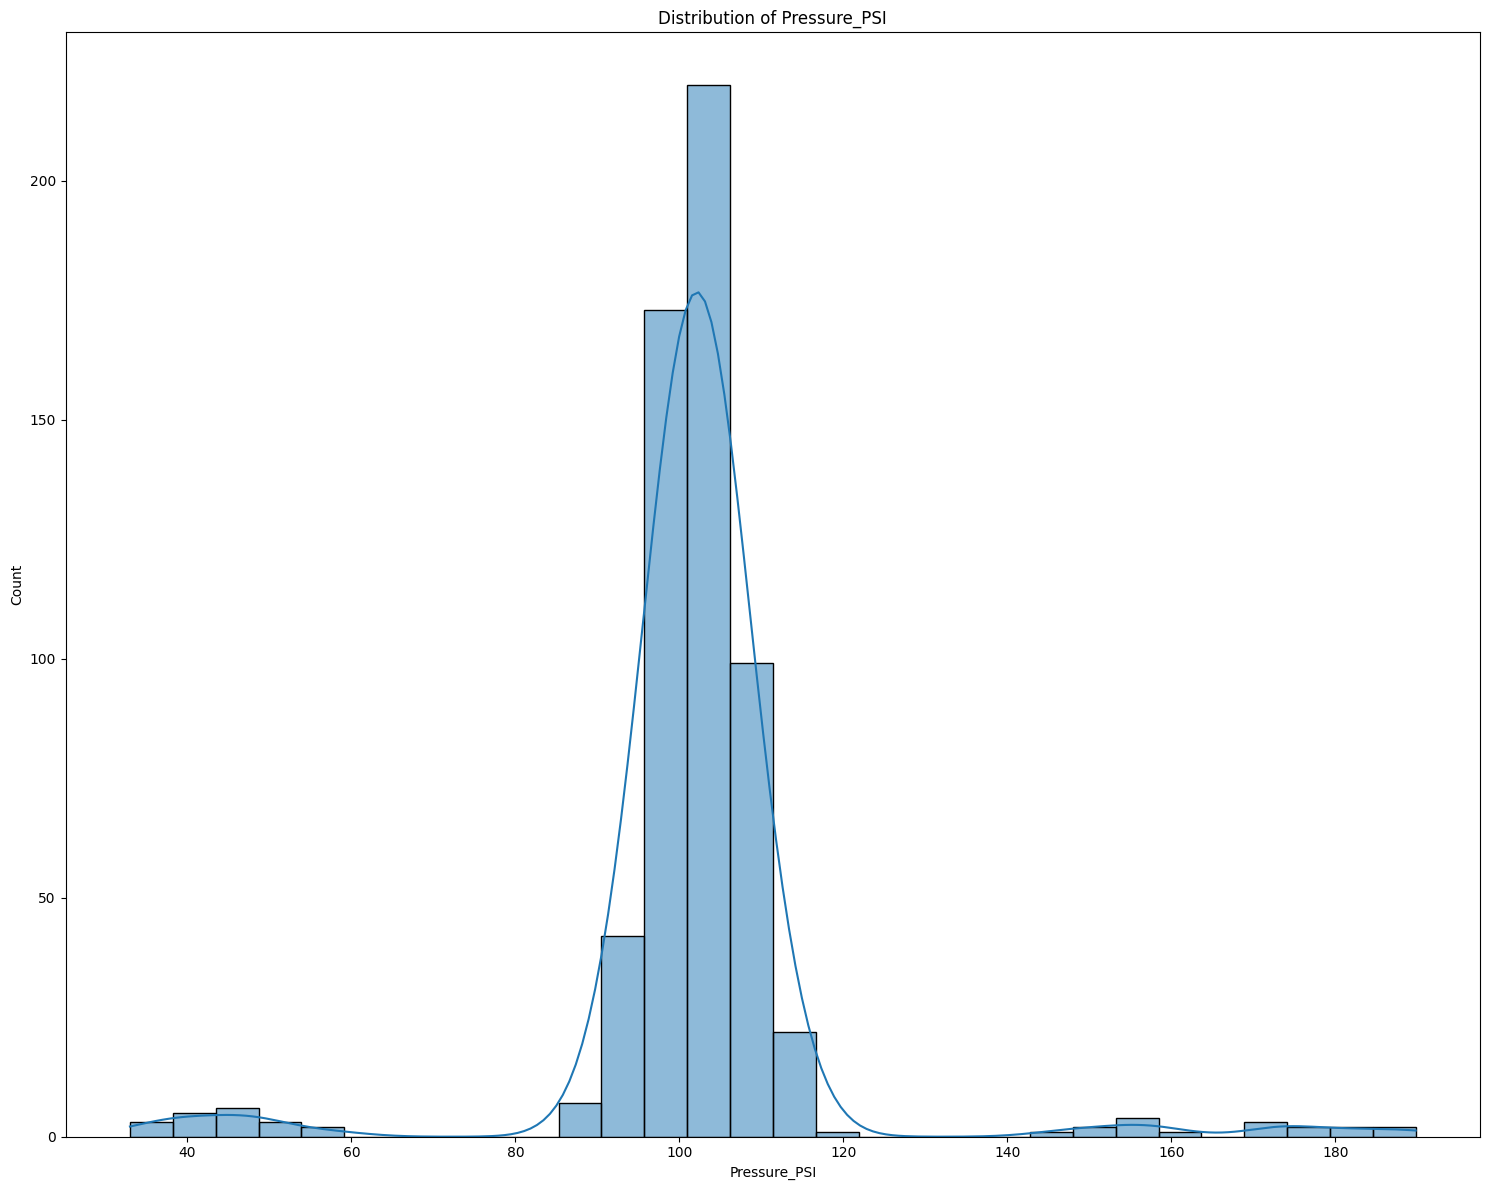

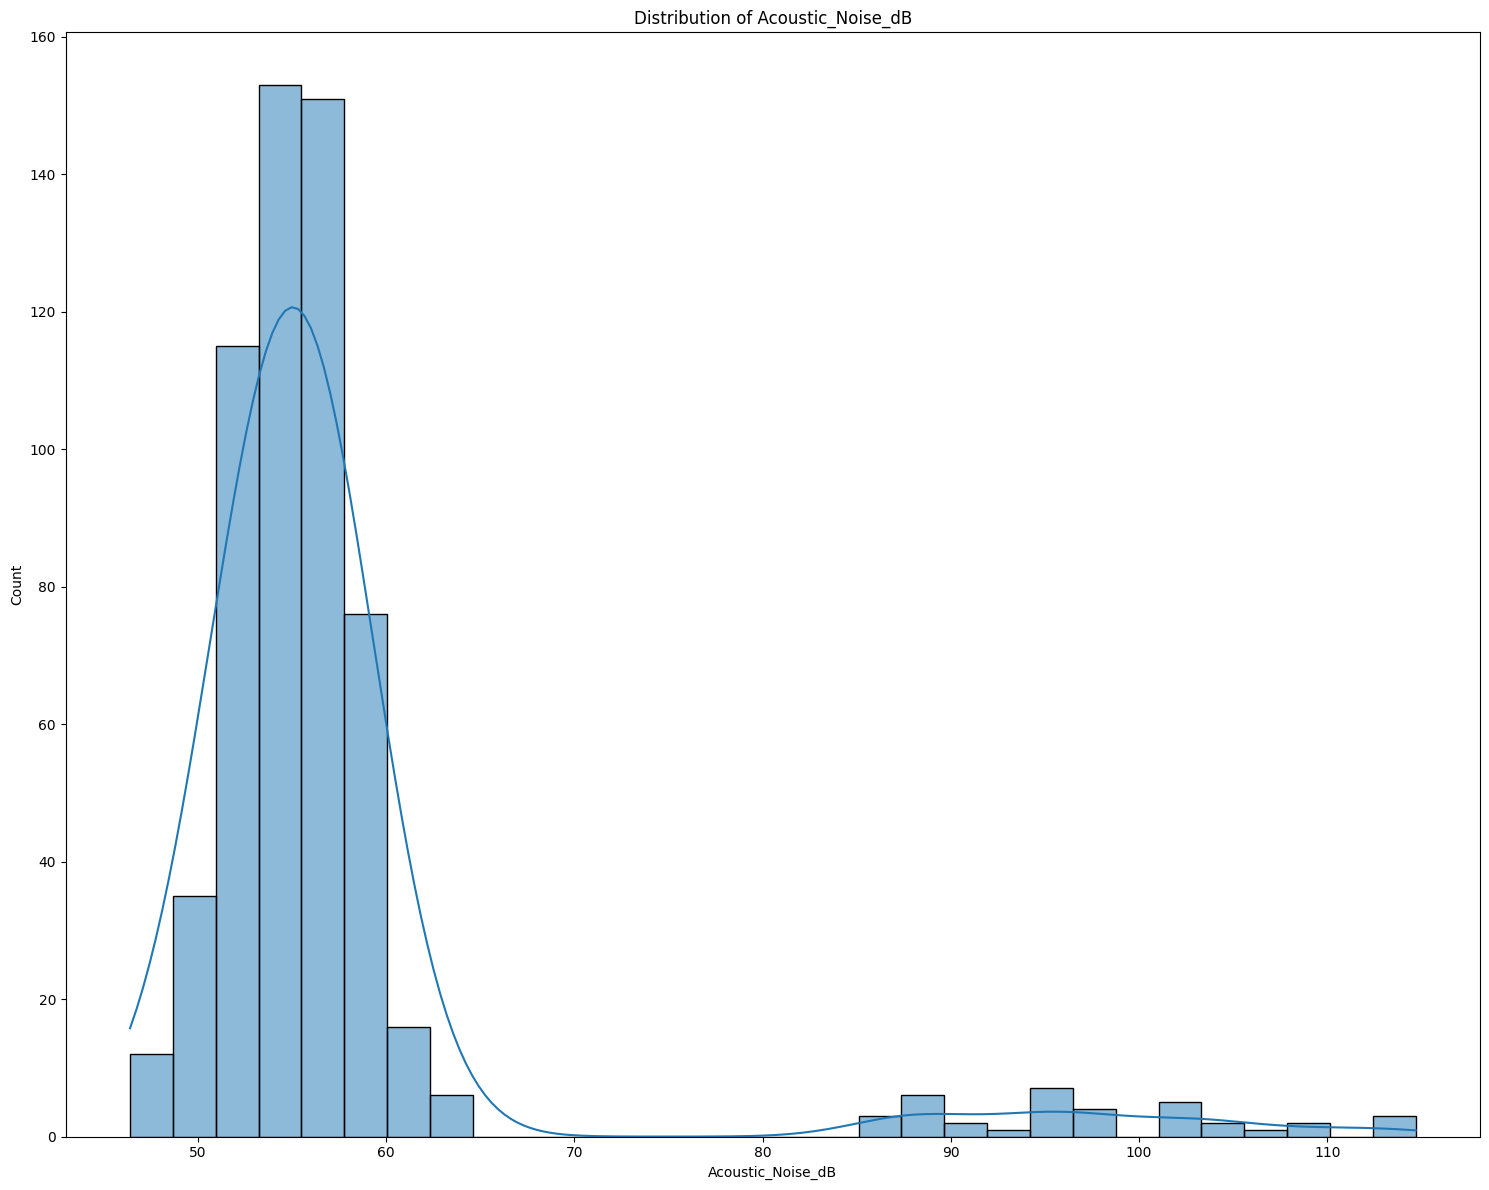

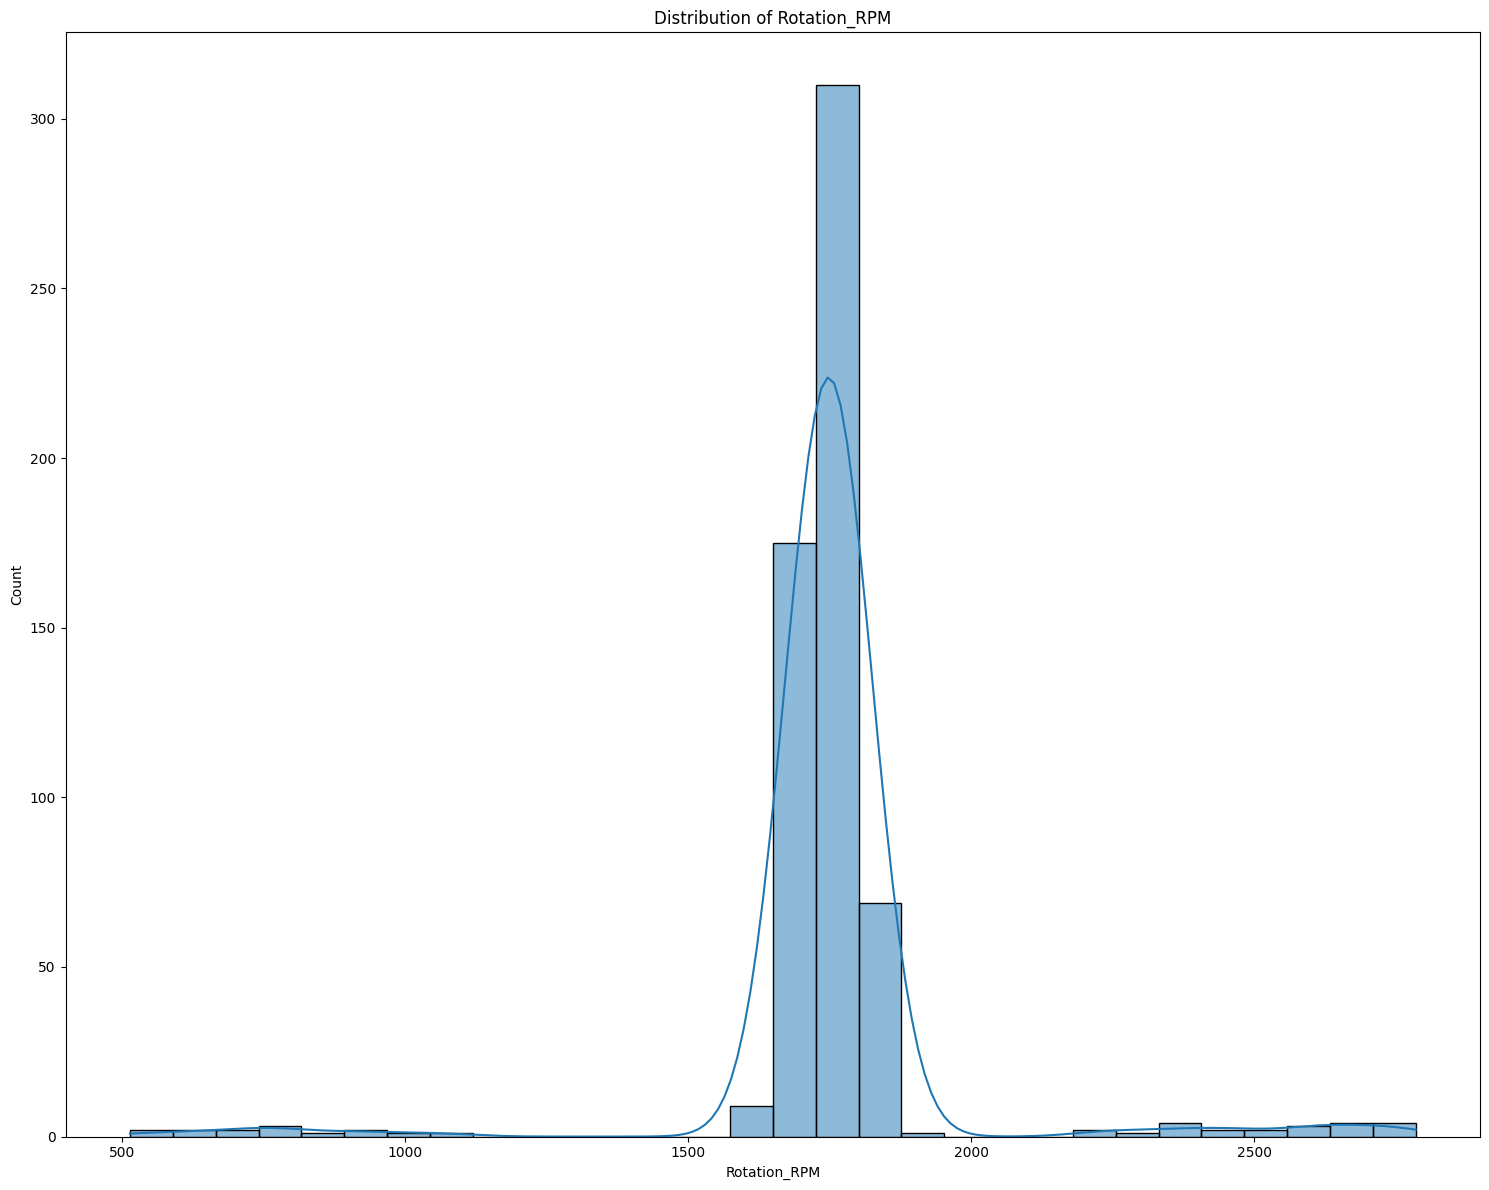

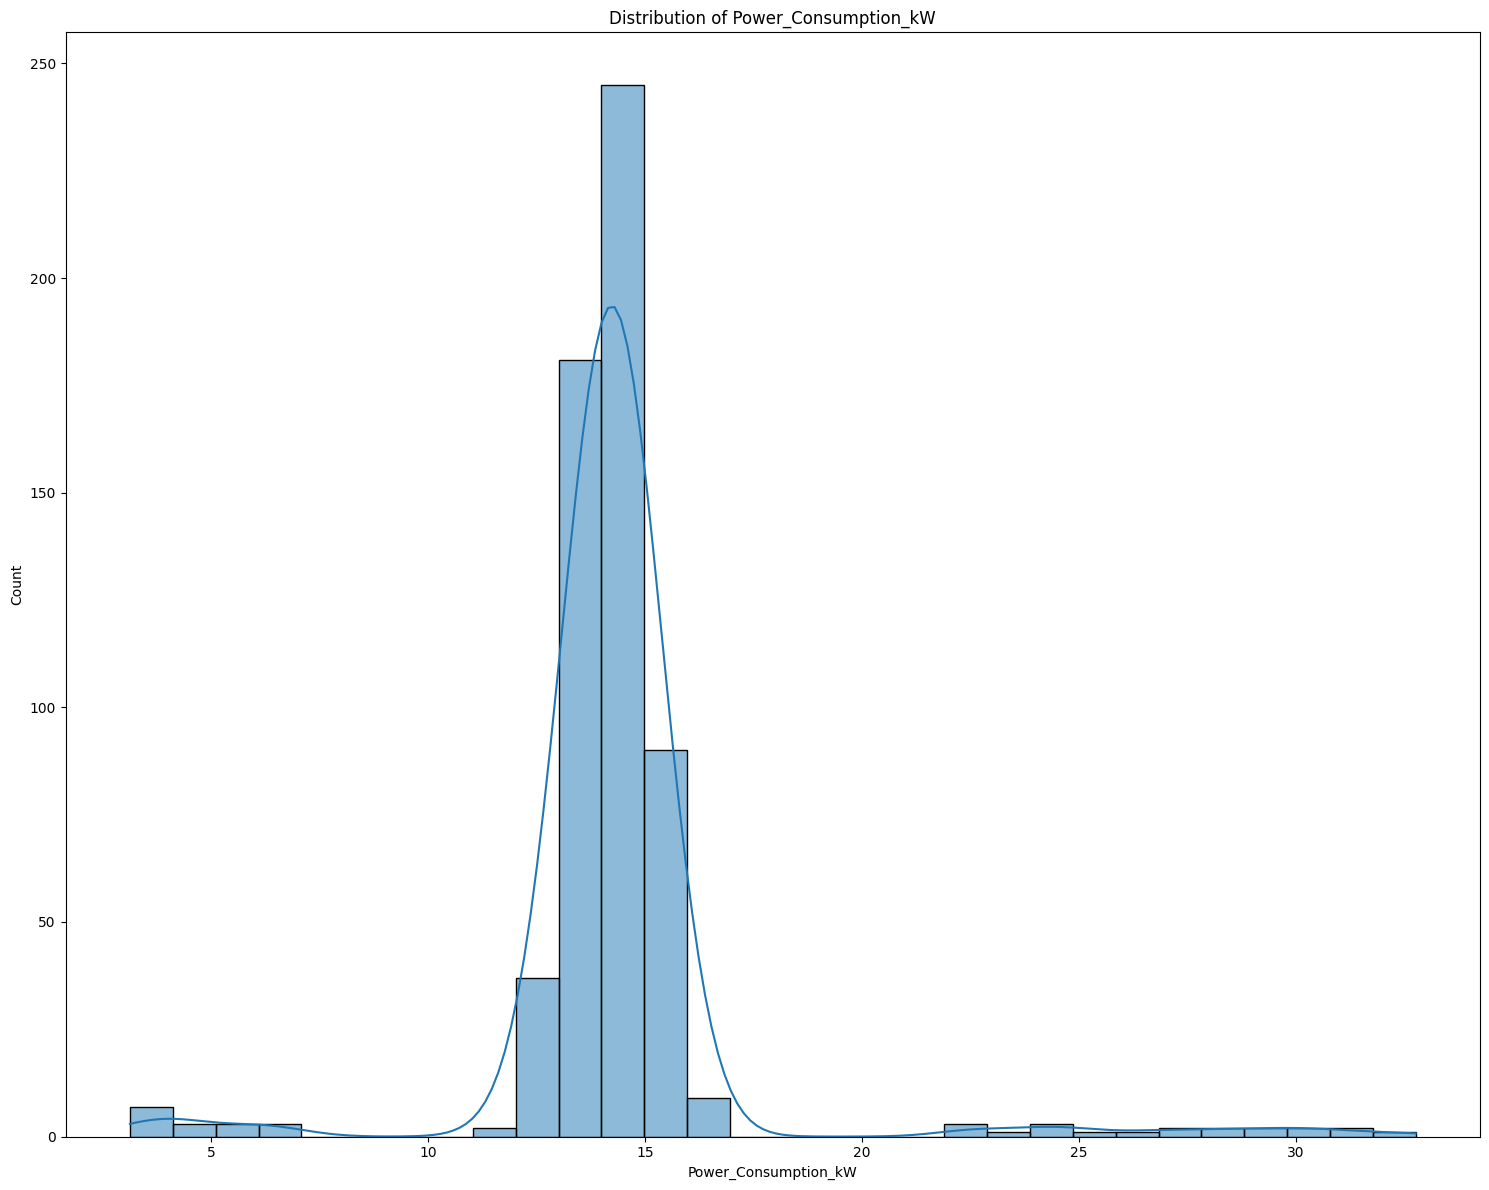


Rule-Based Reference Label Distribution:
reference_label
0    564
1     36
Name: count, dtype: int64
reference_label
0    94.0
1     6.0
Name: proportion, dtype: float64


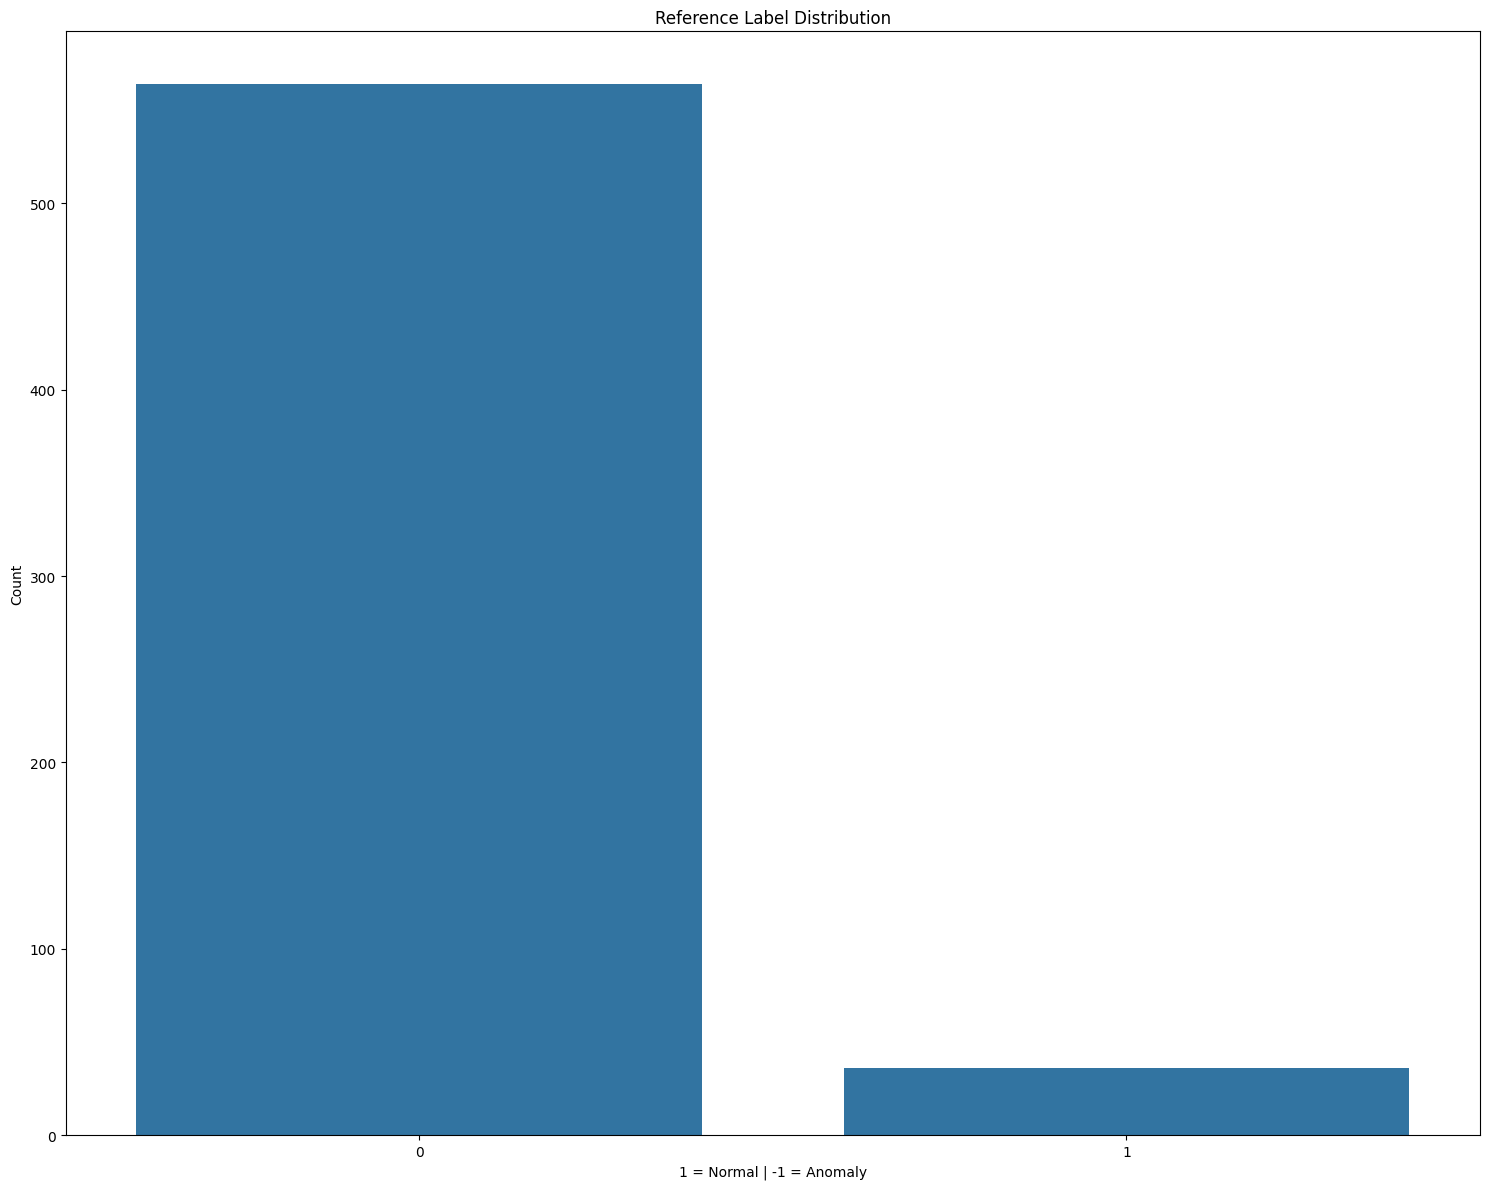


Selected Features:
['Vibration_Hz', 'Temperature_C', 'Pressure_PSI', 'Acoustic_Noise_dB', 'Rotation_RPM', 'Power_Consumption_kW']

X Shape:
(600, 6)

Base Model Prediction Distribution:
Anomaly_Base_Binary
0    570
1     30
Name: count, dtype: int64

Base Model Prediction Distribution:
Anomaly_Base
 1    570
-1     30
Name: count, dtype: int64


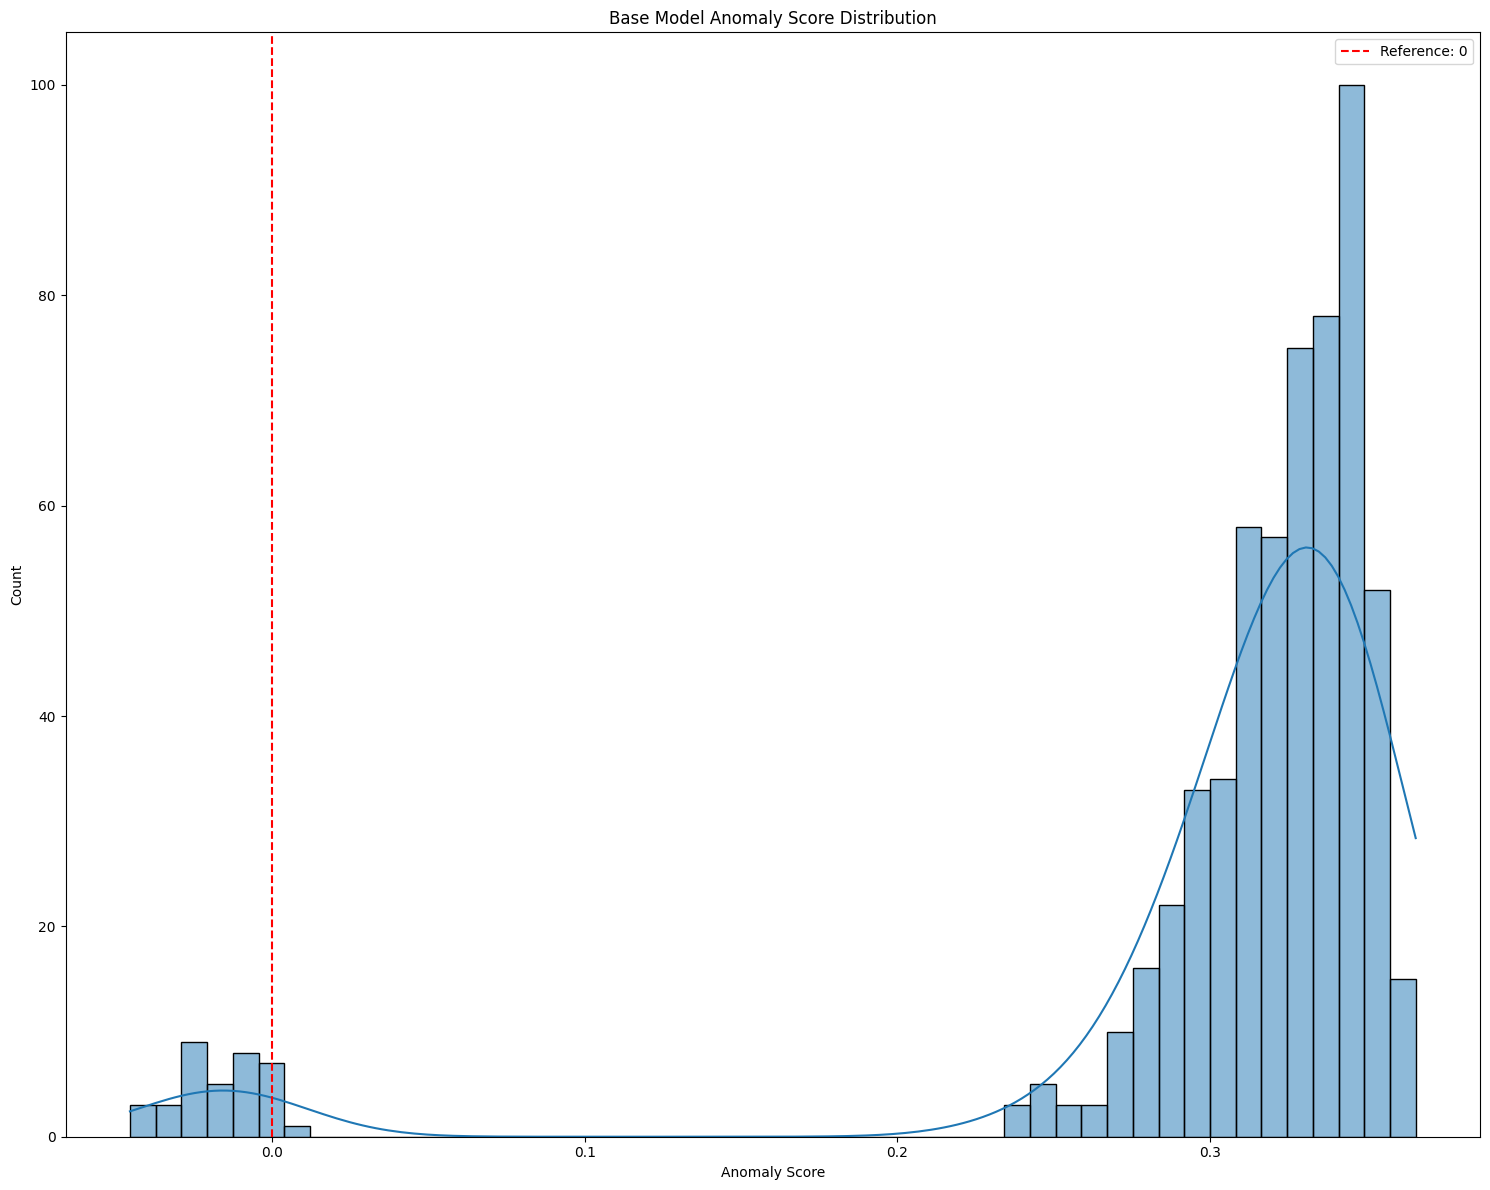


========== BASE MODEL METRICS ==========
Accuracy : 0.99
Precision: 1.0
Recall   : 0.8333333333333334
F1 Score : 0.9090909090909091

Base Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       564
     Anomaly       1.00      0.83      0.91        36

    accuracy                           0.99       600
   macro avg       0.99      0.92      0.95       600
weighted avg       0.99      0.99      0.99       600


Base Model Confusion Matrix:
[[564   0]
 [  6  30]]


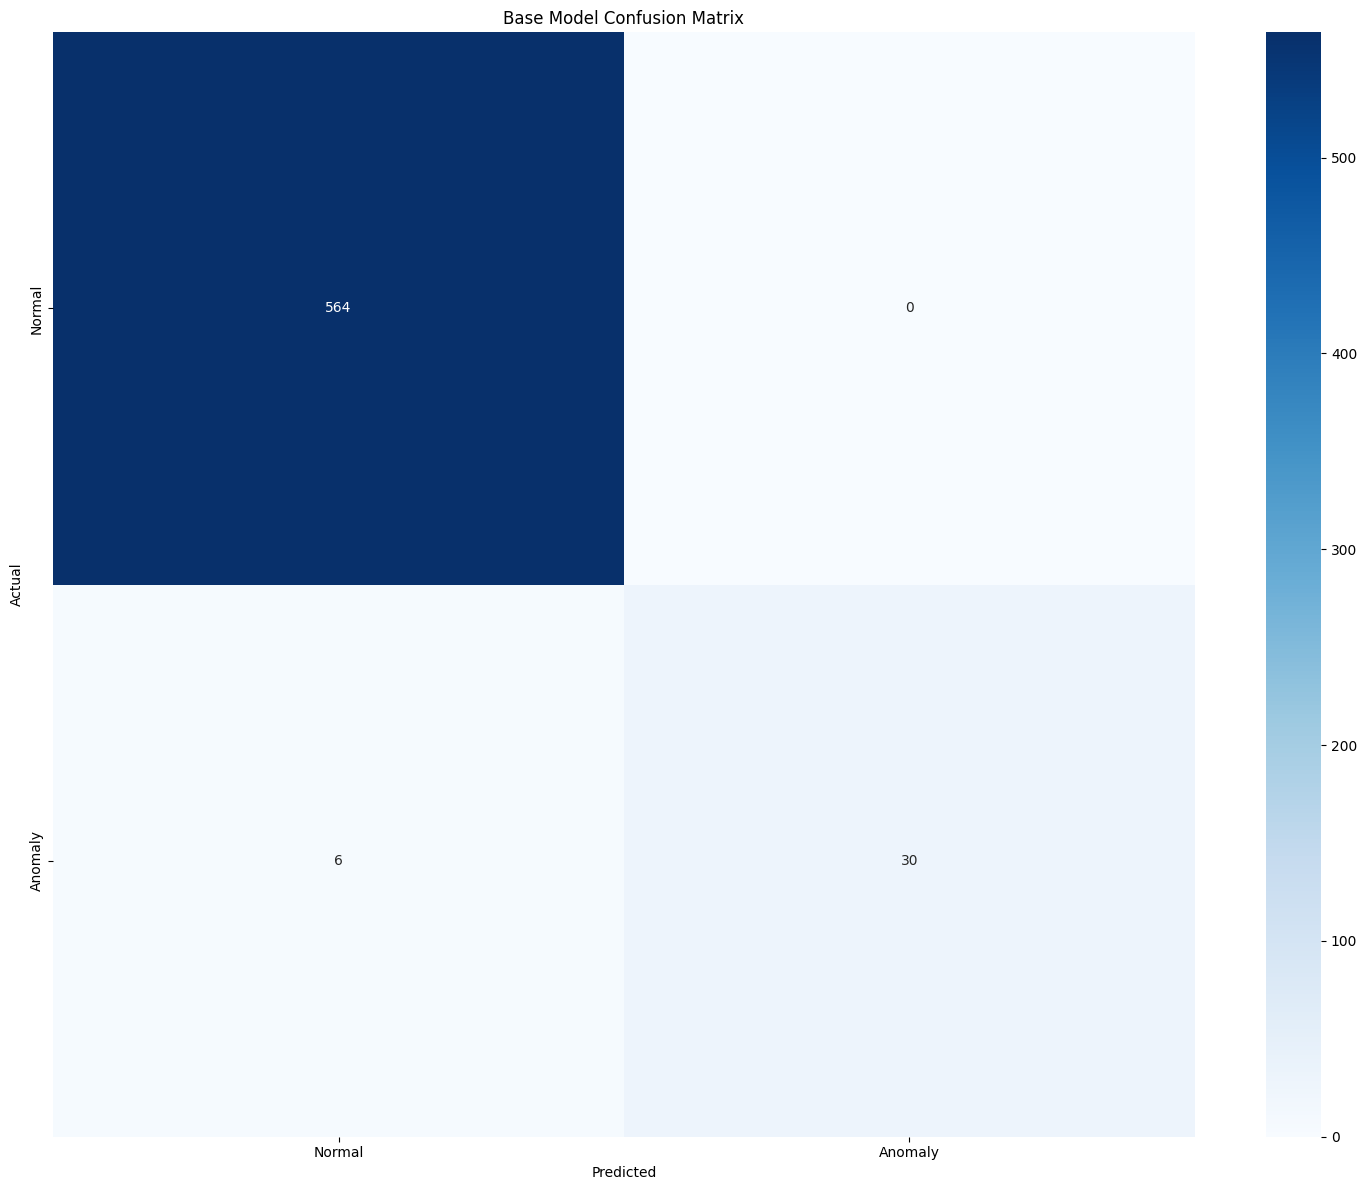


Testing Parameters:
{'n_estimators': 100, 'max_samples': 'auto', 'contamination': 0.05, 'max_features': 1.0, 'bootstrap': False, 'n_jobs': -1}

Testing Parameters:
{'n_estimators': 200, 'max_samples': 'auto', 'contamination': 0.05, 'max_features': 1.0, 'bootstrap': False, 'n_jobs': -1}

Testing Parameters:
{'n_estimators': 300, 'max_samples': 'auto', 'contamination': 0.05, 'max_features': 1.0, 'bootstrap': False, 'n_jobs': -1}

Testing Parameters:
{'n_estimators': 200, 'max_samples': 'auto', 'contamination': 0.05, 'max_features': 1.0, 'bootstrap': False, 'n_jobs': -1}

Testing Parameters:
{'n_estimators': 300, 'max_samples': 1.0, 'contamination': 0.1, 'max_features': 1.0, 'bootstrap': False, 'n_jobs': -1}

========== PARAMETER TUNING RESULTS ==========
   n_estimators max_samples  contamination  max_features  bootstrap  n_jobs  \
0           100        auto           0.05           1.0      False      -1   
1           200        auto           0.05           1.0      False      -1   

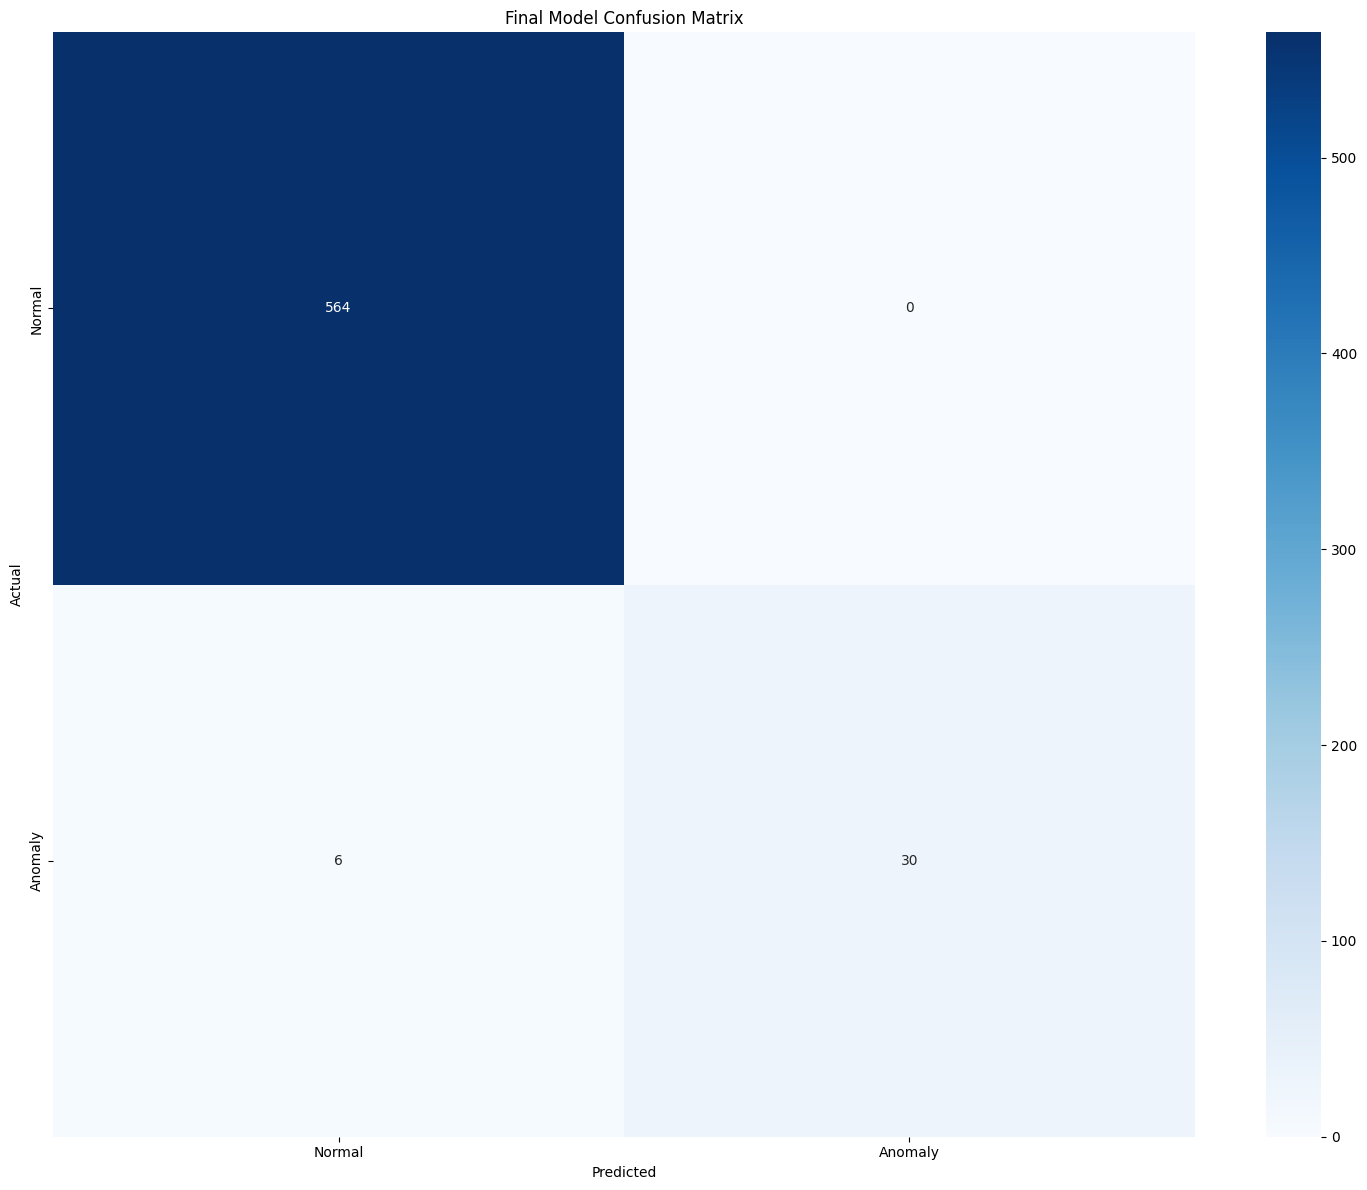

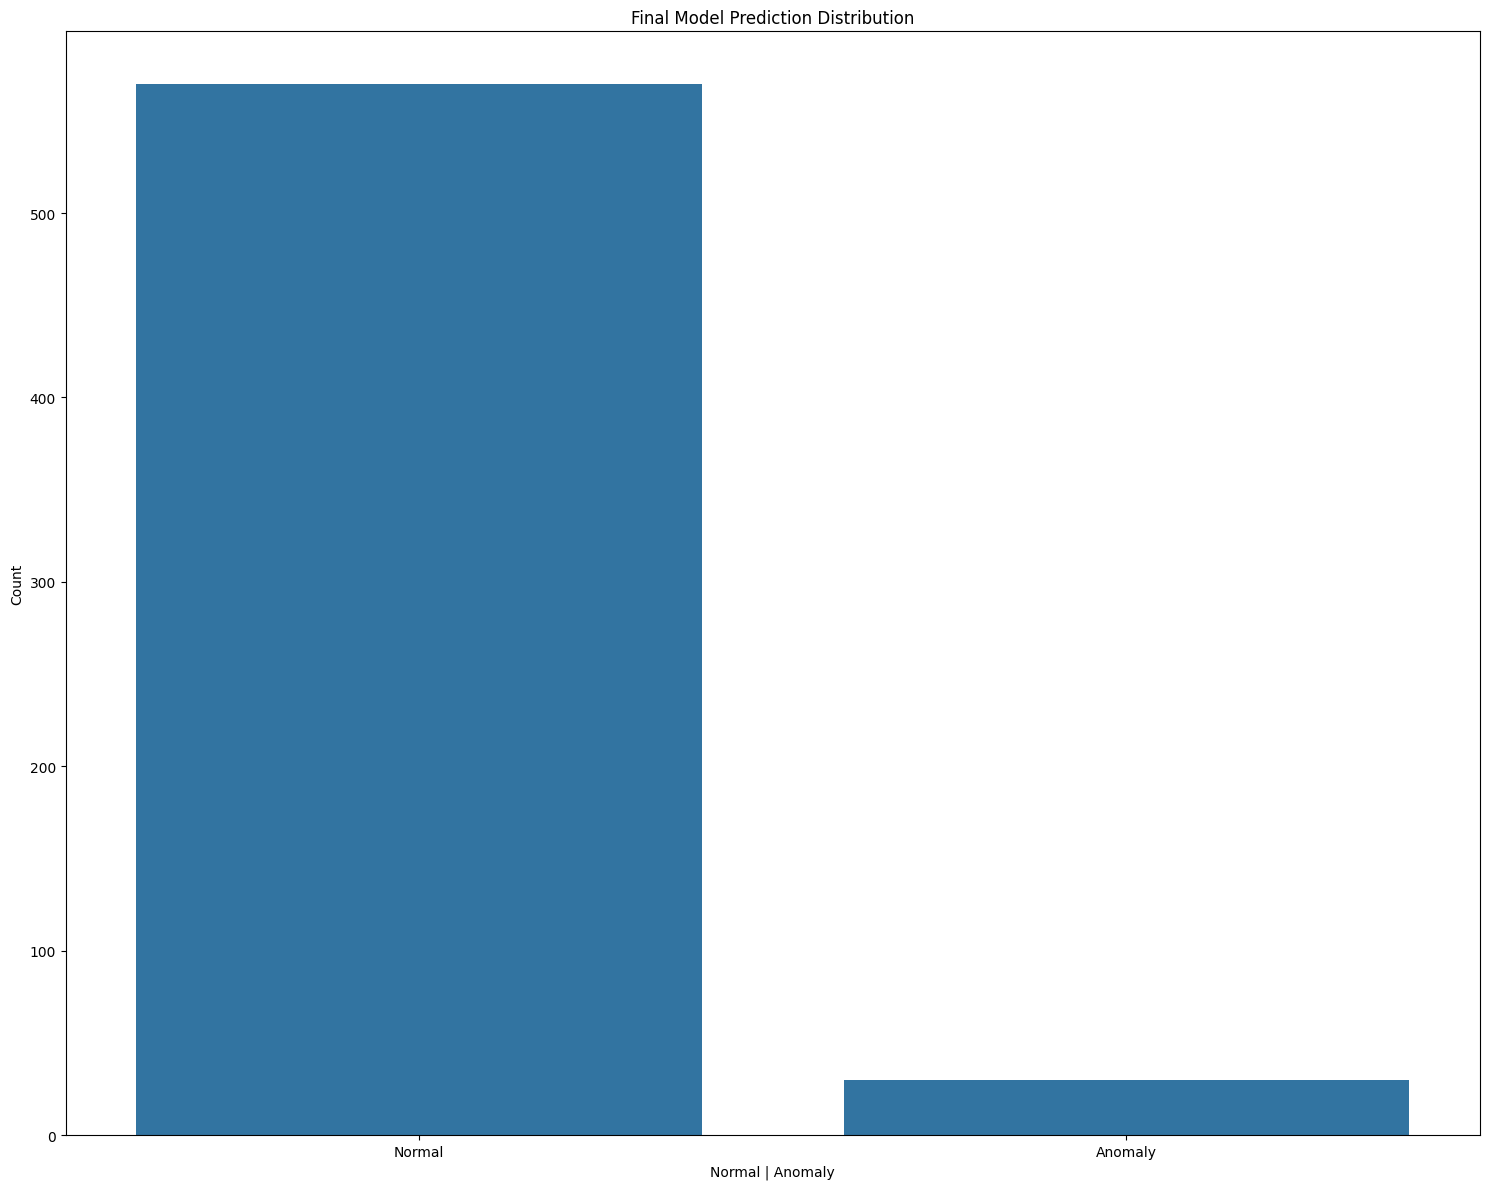


DETECTED ANOMALIES
     Vibration_Hz  Temperature_C  Pressure_PSI  Acoustic_Noise_dB  \
1          107.65           27.2         148.7               96.3   
11         107.77           20.8          46.5              114.7   
34          92.03          105.5         155.4              102.9   
50           5.77           93.3          46.7              112.5   
69           9.31           28.4          49.0              109.6   
139        124.42           23.2         172.1               86.8   
140        116.28           21.1          33.0              105.7   
154         12.81          113.7         150.0               96.2   
226         16.83           99.5         183.6               88.0   
241        104.96           34.3         189.8               98.2   
247         89.99          115.0          39.0               88.4   
261        106.25          118.3         158.3               88.8   
305         12.52          100.3         183.3               85.4   
313         13

In [3]:
# STEP 1 — IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import(
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# STEP 2 — LOAD DATASET
df = pd.read_csv("/content/machine_sensor_telemetry.csv")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())


# STEP 3 — CHECK INFINITE VALUES + REPLACE INFINITY WITH NaN
num_cols = df.select_dtypes(include=np.number).columns

print("\nInfinite Values:")
print(np.isinf(df[num_cols]).sum())

df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# STEP 4 — REMOVE NaN VALUES
df.dropna(inplace=True)

# STEP 5 — EXPLORATORY DATA ANALYSIS

# Numeric columns only
numerical_columns = df.select_dtypes(include=np.number)

# Correlation Heatmap
plt.figure(figsize=(15,12))

sns.heatmap(
    numerical_columns.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Machine Sensor Anomaly Detection Correlation")
plt.tight_layout()
plt.show()

# Feature Distributions

features_for_plot = [
    "Vibration_Hz",
    "Temperature_C",
    "Pressure_PSI",
    "Acoustic_Noise_dB",
    "Rotation_RPM",
    "Power_Consumption_kW"
]

for features in features_for_plot:

  plt.figure(figsize=(15,12))

  sns.histplot(
      df[features],
      bins=30,
      kde=True
  )
  plt.title(f"Distribution of {features}")
  plt.tight_layout()
  plt.show()



# STEP 6 — CREATE RULE-BASED REFERENCE LABEL (Statistical Trick)

def create_reference_label(row, stats):
  for feature in stats:
    mean, std = stats[feature]
    lower, upper = mean -3*std, mean +3*std
    if row[feature] < lower or row[feature] > upper:
      return 1 # Anomaly
  return 0 # Normal

# Calculate mean & std for each feature
stats = {
    col: (df[col].mean(), df[col].std())
    for col in features_for_plot
}

# Apply rule
df["reference_label"] = df.apply(lambda row: create_reference_label(row, stats), axis=1)

# STEP 7 — CHECK REFERENCE LABEL DISTRIBUTION

print("\nRule-Based Reference Label Distribution:")
print(df["reference_label"].value_counts())
print(df["reference_label"].value_counts(normalize=True).mul(100))

# STEP 8 — VISUALIZE REFERENCE LABEL

plt.figure(figsize=(15,12))
sns.countplot(
    data = df,
    x = "reference_label"
)
plt.title("Reference Label Distribution")
plt.xlabel("1 = Normal | -1 = Anomaly")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



# STEP 9 — SELECT FEATURES

features_df = [
    "Vibration_Hz",
    "Temperature_C",
    "Pressure_PSI",
    "Acoustic_Noise_dB",
    "Rotation_RPM",
    "Power_Consumption_kW"
]

X = df[features_df].copy()

print("\nSelected Features:")
print(features_df)

print("\nX Shape:")
print(X.shape)


# STEP 10 — SCALE FEATURES

scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X)

# STEP 11 — BASELINE ISOLATION FOREST

base_model = IsolationForest(
    n_estimators= 200,
    max_samples= "auto",
    contamination= 0.05,
    max_features= 1.0,
    bootstrap= False,
    n_jobs= -1,
    random_state= 42
)

# STEP 12 — BASE MODEL PREDICTION

base_prediction = base_model.fit_predict(X_Scaled)

# Isolation Forest:
#
#  1  = Normal
# -1  = Anomaly

df["Anomaly_Base"] = base_prediction

# STEP 13 — CONVERT ISOLATION FOREST OUTPUT
# Convert Isolation Forest output (1=Normal, -1=Anomaly) → 0/1
df["Anomaly_Base_Binary"] = pd.Series(base_prediction).map({1:0, -1:1})

print("\nBase Model Prediction Distribution:")
print(df["Anomaly_Base_Binary"].value_counts())

# STEP 13 — BASE MODEL DISTRIBUTION
print("\nBase Model Prediction Distribution:")
print(df["Anomaly_Base"].value_counts())


# STEP 14 - BASE ANOMALY SCORE

df["Anomaly_Base_Score"] = base_model.decision_function(X_Scaled)

# STEP 15 — ANOMALY SCORE VISUALIZATION

plt.figure(figsize=(15,12))
sns.histplot(
    df["Anomaly_Base_Score"],
    bins=50,
    kde=True
)
plt.axvline(
    0,
    linestyle="--",
    label="Reference: 0",
    color="red"
)
plt.legend()
plt.title("Base Model Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# STEP 16 — BASE MODEL EVALUATION

base_accuracy = accuracy_score(df["reference_label"], df["Anomaly_Base_Binary"])
base_precision = precision_score(df["reference_label"], df["Anomaly_Base_Binary"], zero_division=0)
base_recall = recall_score(df["reference_label"], df["Anomaly_Base_Binary"], zero_division=0)
base_f1 = f1_score(df["reference_label"], df["Anomaly_Base_Binary"], zero_division=0)

print("\n========== BASE MODEL METRICS ==========")
print("Accuracy :", base_accuracy)
print("Precision:", base_precision)
print("Recall   :", base_recall)
print("F1 Score :", base_f1)

print("\nBase Classification Report:")
print(classification_report(
    df["reference_label"],
    df["Anomaly_Base_Binary"],
    target_names=["Normal", "Anomaly"],
    zero_division=0
))

# STEP 17 — BASE MODEL CONFUSION MATRIX HEATMAP

# BASE MODEL CONFUSION MATRIX
base_cm = confusion_matrix(
    df["reference_label"],
    df["Anomaly_Base_Binary"]
)
print("\nBase Model Confusion Matrix:")
print(base_cm)

plt.figure(figsize=(15,12))

sns.heatmap(
    base_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"]
)
plt.title("Base Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



# STEP 18 — MANUAL PARAMETER TUNING

parameter_combinations = [
    {
        "n_estimators": 100,
        "max_samples": "auto",
        "contamination": 0.05,
        "max_features": 1.0,
        "bootstrap": False,
        "n_jobs": -1,
    },
    {
        "n_estimators": 200,
        "max_samples": "auto",
        "contamination": 0.05,
        "max_features": 1.0,
        "bootstrap": False,
        "n_jobs": -1,
    },
    {
        "n_estimators": 300,
        "max_samples": "auto",
        "contamination": 0.05,
        "max_features": 1.0,
        "bootstrap": False,
        "n_jobs": -1,
    },
    {
        "n_estimators": 200,
        "max_samples": "auto",
        "contamination": 0.05,
        "max_features": 1.0,
        "bootstrap": False,
        "n_jobs": -1,
    },
    {
        "n_estimators": 300,
        "max_samples": 1.0,
        "contamination": 0.10,
        "max_features": 1.0,
        "bootstrap": False,
        "n_jobs": -1,
    }
]

# STEP 19 — RUN PARAMETER COMBINATIONS

tuning_results = []

for params in parameter_combinations:
  print("\nTesting Parameters:")
  print(params)

  temp_model = IsolationForest(
      n_estimators= params["n_estimators"],
      max_samples= params["max_samples"],
      contamination= params["contamination"],
      max_features= params["max_features"],
      bootstrap= params["bootstrap"],
      n_jobs= params["n_jobs"],
      random_state= 42
  )

  # Train + Predict
  temp_prediction = temp_model.fit_predict(X_Scaled)

  # Convert:
    # 1  → 0 Normal
    # -1 → 1 Anomaly

  temp_binary = pd.Series(temp_prediction).map({1:0, -1:1})

  # Metrics
  temp_accuracy = accuracy_score(df["reference_label"], temp_binary)
  temp_precision = precision_score(df["reference_label"], temp_binary, zero_division=0)
  temp_recall = recall_score(df["reference_label"], temp_binary, zero_division=0)
  temp_f1 = f1_score(df["reference_label"], temp_binary, zero_division=0)

  # Store results
  tuning_results.append({
      "n_estimators": params["n_estimators"],
      "max_samples": params["max_samples"],
      "contamination": params["contamination"],
      "max_features": params["max_features"],
      "bootstrap": params["bootstrap"],
      "n_jobs": params["n_jobs"],
      "accuracy": temp_accuracy,
      "precision": temp_precision,
      "recall": temp_recall,
      "f1": temp_f1
  })

# STEP 20 — TUNING RESULTS

tuning_df = pd.DataFrame(
    tuning_results
)

print("\n========== PARAMETER TUNING RESULTS ==========")

print(tuning_df.sort_values(by="f1", ascending=False))


# STEP 21 — SELECT BEST PARAMETERS

best_index = tuning_df["f1"].idxmax()

best_params = {
    "n_estimators": int(tuning_df.loc[best_index, "n_estimators"]),
    "max_samples": tuning_df.loc[best_index, "max_samples"],
    "contamination": float(tuning_df.loc[best_index, "contamination"]),
    "max_features": float(tuning_df.loc[best_index, "max_features"]),
}

print("\n========== BEST PARAMETERS ==========")
print(best_params)
print("\nBest F1 Score:", tuning_df.loc[best_index, "f1"])

# STEP 22 — CREATE FINAL MODEL

final_model = IsolationForest(
    n_estimators= best_params["n_estimators"],
    max_samples= best_params["max_samples"],
    contamination= best_params["contamination"],
    max_features= best_params["max_features"],
    random_state= 42
)

# STEP 23 — FINAL MODEL PREDICTION

final_prediction = final_model.fit_predict(X_Scaled)

df["Final_Anomaly"] = final_prediction

# STEP 24 — CONVERT FINAL PREDICTION TO BINARY

df["Final_Anomaly_Binary"] = df["Final_Anomaly"].map({
    1: 0,
    -1: 1
})

# STEP 25 — FINAL ANOMALY SCORE

df["Final_Anomaly_Score"] = final_model.decision_function(X_Scaled)

# STEP 26 — FINAL STATUS
df["Final_Status"] = (
    df["Final_Anomaly"].map({
        1: "Normal",
        -1: "Anomaly"
    })

)

# STEP 27 — FINAL EVALUATION

final_cm = confusion_matrix(
    df["reference_label"],
    df["Final_Anomaly_Binary"]
)

print("\nFinal Model Confusion Matrix:")
print(final_cm)

final_accuracy = accuracy_score(df["reference_label"], df["Final_Anomaly_Binary"])
final_precision = precision_score(df["reference_label"], df["Final_Anomaly_Binary"], zero_division=0)
final_recall = recall_score(df["reference_label"], df["Final_Anomaly_Binary"], zero_division=0)
final_f1 = f1_score(df["reference_label"], df["Final_Anomaly_Binary"], zero_division=0)

print("\n==========================================")
print("FINAL MODEL EVALUATION")
print("==========================================")
print("\nConfusion Matrix:")
print(final_cm)
print("\nAccuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall :", final_recall)
print("F1 Score :", final_f1)

print("\nClassification Report:")
print(classification_report(
    df["reference_label"],
    df["Final_Anomaly_Binary"],
    target_names=["Normal", "Anomaly"],
    zero_division=0
))


# STEP 28 — FINAL CONFUSION MATRIX HEATMAP

plt.figure(figsize=(15,12))

sns.heatmap(
    final_cm,
    annot = True,
    fmt = "d",
    xticklabels = ["Normal", "Anomaly"],
    yticklabels = ["Normal", "Anomaly"],
    cmap = "Blues"
)
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# STEP 29 — FINAL PREDICTION DISTRIBUTION
plt.figure(figsize=(15,12))

sns.countplot(
    data = df,
    x = "Final_Status"
)
plt.title("Final Model Prediction Distribution")
plt.xlabel("Normal | Anomaly")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# STEP 30 — SHOW DETECTED ANOMALIES
anomalies = df[
    df["Final_Anomaly"] == -1
]

print("\n==========================================")
print("DETECTED ANOMALIES")
print("==========================================")

print(anomalies[
    [
        "Vibration_Hz",
        "Temperature_C",
        "Pressure_PSI",
        "Acoustic_Noise_dB",
        "Rotation_RPM",
        "Power_Consumption_kW"
    ]
])


# STEP 31 — ANOMALY COUNT & PERCENTAGE

anomaly_count = (df["Final_Anomaly"] == -1).sum()
normal_count = (df["Final_Anomaly"] == 1).sum()

total_count = anomaly_count + normal_count

anomaly_percentage = (anomaly_count / total_count) * 100
normal_percentage = (normal_count / total_count) * 100


print("\n==========================================")
print("FINAL ANOMALY SUMMARY")
print("==========================================")

print("Total Records :", total_count)
print("Normal Records:", normal_count)
print("Anomalies :", anomaly_count)

print( "Anomaly Percentage:", anomaly_percentage )
print( "Normal Percentage:", normal_percentage )

# STEP 32 — SAVE ANOMALIES ONLY
anomalies.to_csv("/content/detected_network_anomalies.csv", index=False)

print( "\nDetected anomalies saved to:" " /content/detected_network_anomalies.csv" )

